In [144]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV

In [60]:
data = sns.get_dataset_names()

In [61]:
diamonds_data = sns.load_dataset('diamonds')

In [62]:
diamonds_data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [63]:
diamonds_data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [64]:
diamonds_data.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [65]:
#Performing EDA on dataset
#Searching for unique values
Carat = diamonds_data['carat'].unique()
Cut = diamonds_data['cut'].unique()
Clarity = diamonds_data['clarity'].unique()
print(Carat)
print()
print(Cut)
print()
print(Clarity)

[0.23 0.21 0.29 0.31 0.24 0.26 0.22 0.3  0.2  0.32 0.33 0.25 0.35 0.42
 0.28 0.38 0.7  0.86 0.71 0.78 0.96 0.73 0.8  0.75 0.74 0.81 0.59 0.9
 0.91 0.61 0.77 0.63 0.76 0.64 0.72 0.79 0.58 1.17 0.6  0.83 0.54 0.98
 0.52 1.01 0.53 0.84 0.51 1.05 0.55 0.87 1.   0.57 0.82 1.04 0.93 1.2
 0.99 0.34 0.43 0.36 0.95 0.89 1.02 0.97 0.56 0.85 0.92 1.27 0.66 1.12
 0.68 1.03 0.62 1.22 1.08 0.88 0.5  1.19 0.39 0.65 1.24 1.5  0.27 0.41
 1.13 1.06 0.69 0.4  1.14 0.94 1.29 1.52 1.16 1.21 1.23 1.09 0.67 1.11
 1.1  1.18 1.15 1.25 1.07 1.28 1.51 0.37 1.31 1.26 1.39 1.44 1.35 1.3
 1.32 1.41 1.36 1.45 1.34 1.58 1.54 1.38 1.33 1.74 1.64 1.47 1.4  1.55
 1.95 2.   1.37 1.83 1.62 1.57 1.69 2.06 1.72 1.66 2.14 1.49 1.46 2.15
 1.96 2.22 1.7  1.53 1.85 2.01 2.27 1.68 1.56 1.81 1.65 1.82 2.03 1.73
 1.59 1.42 1.43 2.08 1.48 1.6  2.49 1.71 2.02 2.07 3.   2.21 2.1  1.91
 2.25 2.17 2.32 2.72 1.61 2.23 2.11 2.05 1.63 2.3  2.31 1.75 2.04 2.12
 1.77 2.5  1.8  1.67 1.84 2.2  3.01 1.88 2.33 2.68 2.34 1.9  2.16 2.74
 1.78 1.7

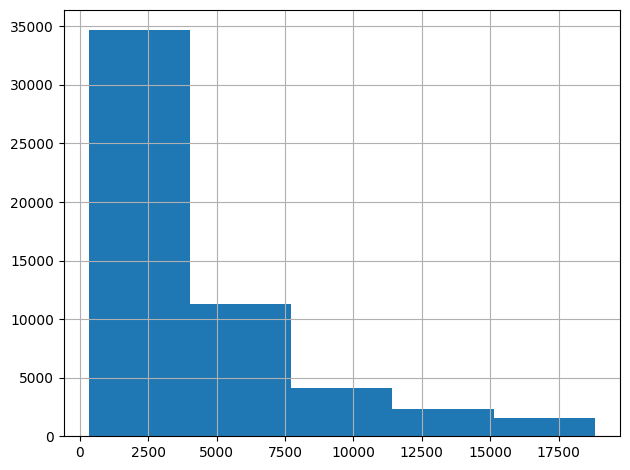

In [66]:
price = diamonds_data['price']
plt.hist(price,bins=5,label="Prices Comparsion of diamonds")
plt.tight_layout()
plt.grid(True)

(array([4.3781e+04, 9.4780e+03, 6.6700e+02, 1.1000e+01, 3.0000e+00]),
 array([0.2  , 1.162, 2.124, 3.086, 4.048, 5.01 ]),
 <BarContainer object of 5 artists>)

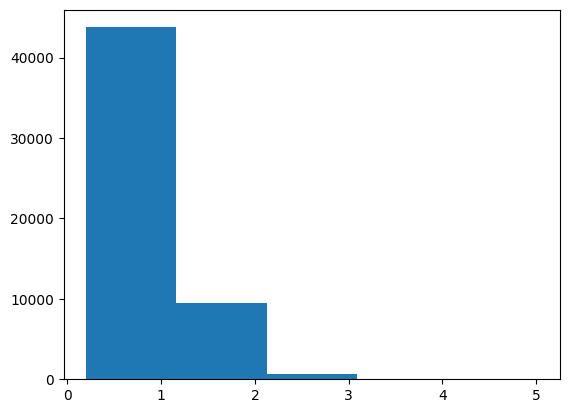

In [67]:
carat = diamonds_data['carat']
plt.hist(carat,bins=5,label="variety of Carats available")

(array([21551., 13791.,     0.,  4906., 12082.,  1610.]),
 array([0.        , 0.66666667, 1.33333333, 2.        , 2.66666667,
        3.33333333, 4.        ]),
 <BarContainer object of 6 artists>)

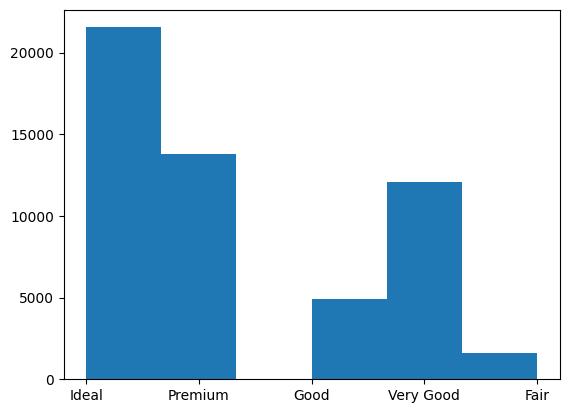

In [68]:
cut = diamonds_data['cut']
plt.hist(cut,bins=6,label='Quality of Cut')

(array([22259.,  8171., 12258.,  5066.,  3655.,  2531.]),
 array([0.        , 1.16666667, 2.33333333, 3.5       , 4.66666667,
        5.83333333, 7.        ]),
 <BarContainer object of 6 artists>)

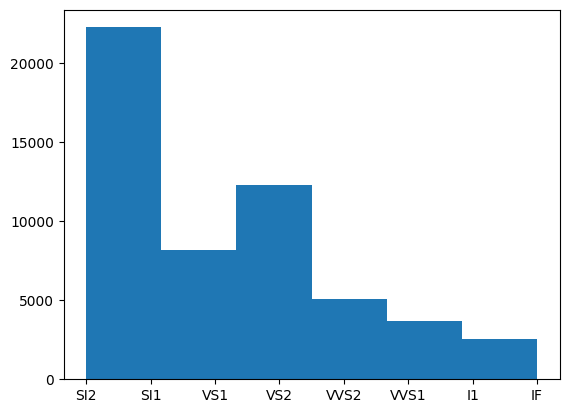

In [69]:
clarity = diamonds_data['clarity']
plt.hist(clarity,bins=6,label="Clarity comaprsion")

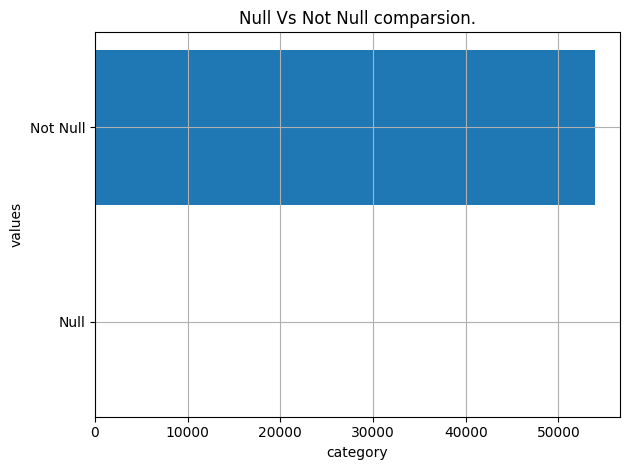

In [70]:
null_count = diamonds_data['price'].isnull().sum()
not_null_count = diamonds_data["price"].notnull().sum()
#print(null_count,not_null_count)
plt.barh(["Null","Not Null"],[null_count,not_null_count])
plt.xlabel("category")
plt.ylabel("values")
plt.title("Null Vs Not Null comparsion.")
plt.grid(True)
plt.tight_layout()

In [71]:
cut = diamonds_data['cut']
color = diamonds_data['color']

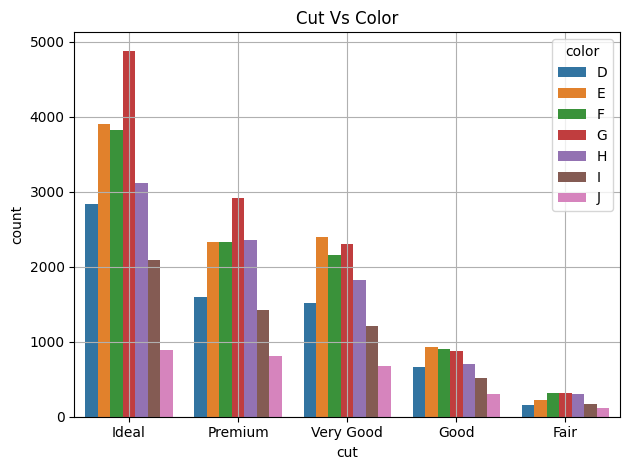

In [72]:
sns.countplot(x=cut,hue=color,data=diamonds_data)
plt.title("Cut Vs Color")
plt.tight_layout()
plt.grid(True)

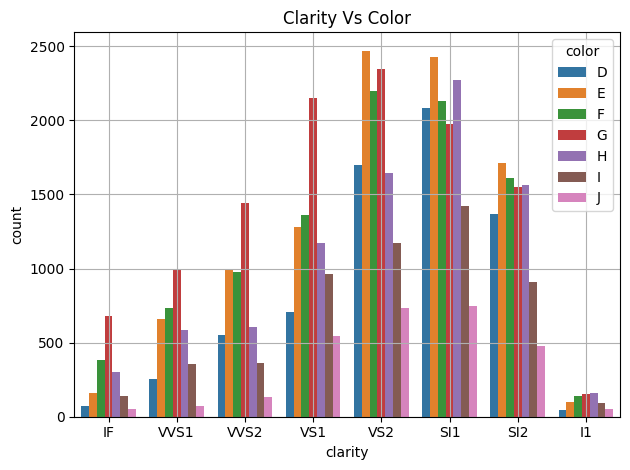

In [73]:
clarity = diamonds_data['clarity']
sns.countplot(x=clarity,hue=color,data=diamonds_data)
plt.title("Clarity Vs Color")
plt.tight_layout()
plt.grid(True)

In [74]:
diamonds_data["price_in_indian_rupee"] = diamonds_data['price']*96.30

In [75]:
diamonds_data

,carat,cut,color,clarity,depth,table,price,x,y,z,price_in_indian_rupee
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,31393.8
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,31393.8
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,31490.1
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,32164.2
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,32260.5
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,265499.1
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,265499.1
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,265499.1
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,265499.1


In [76]:
#Making an copy of the data before modification
copy_diamonds_data = diamonds_data.copy()
copy_diamonds_data

,carat,cut,color,clarity,depth,table,price,x,y,z,price_in_indian_rupee
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,31393.8
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,31393.8
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,31490.1
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,32164.2
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,32260.5
...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50,265499.1
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61,265499.1
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56,265499.1
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74,265499.1


In [77]:
#converting all categorical data into a numerical values
#converting the cut values into numbers
# Fair < good < very good < Premium < Ideal
cut_map = {'Fair':1,"Good":2,"Very Good":3,"Premium":4,"Ideal":5}
copy_diamonds_data['cut'] = copy_diamonds_data['cut'].map(cut_map)

color_map = {'J':1,"I":2,"H":3,"G":4,"F":5,"E":6,"D":7}
copy_diamonds_data['color'] = copy_diamonds_data['color'].map(color_map)

clarity_map = {'I1': 1,'SI2': 2,'SI1': 3,'VS2': 4,'VS1': 5,'VVS2': 6,'VVS1': 7,'IF': 8}
copy_diamonds_data['clarity'] = copy_diamonds_data['clarity'].map(clarity_map)

In [78]:
# Clean out mathematically impossible 0-dimension rows
copy_diamonds_data = copy_diamonds_data[(copy_diamonds_data['x'] > 0) & (copy_diamonds_data['y'] > 0) & (copy_diamonds_data['z'] > 0)].reset_index(drop=True)

In [79]:
copy_diamonds_data

,carat,cut,color,clarity,depth,table,price,x,y,z,price_in_indian_rupee
0,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43,31393.8
1,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31,31393.8
2,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31,31490.1
3,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63,32164.2
4,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75,32260.5
...,...,...,...,...,...,...,...,...,...,...,...
53915,0.72,5,7,3,60.8,57.0,2757,5.75,5.76,3.50,265499.1
53916,0.72,2,7,3,63.1,55.0,2757,5.69,5.75,3.61,265499.1
53917,0.70,3,7,3,62.8,60.0,2757,5.66,5.68,3.56,265499.1
53918,0.86,4,3,2,61.0,58.0,2757,6.15,6.12,3.74,265499.1


In [102]:
split = StratifiedShuffleSplit(n_splits=1,test_size=0.1,random_state=78)
for train_index,test_index in split.split(copy_diamonds_data,copy_diamonds_data['cut']):
  strat_train_set = copy_diamonds_data.loc[train_index]
  strat_test_set = copy_diamonds_data.loc[test_index]

In [103]:
strat_train_set

,carat,cut,color,clarity,depth,table,price,x,y,z,price_in_indian_rupee
37532,0.31,5,6,7,61.0,57.0,988,4.36,4.33,2.65,95144.4
25667,2.04,4,2,2,59.8,59.0,14605,8.30,8.23,4.94,1406461.5
32237,0.30,5,6,6,60.2,57.0,789,4.37,4.40,2.64,75980.7
48030,0.64,4,6,4,61.6,62.0,1926,5.48,5.46,3.37,185473.8
50258,0.70,3,6,3,58.7,60.0,2239,5.85,5.88,3.44,215615.7
...,...,...,...,...,...,...,...,...,...,...,...
53369,0.71,5,6,3,61.7,56.0,2663,5.72,5.75,3.54,256446.9
9726,1.26,5,1,2,62.5,53.0,4656,6.86,6.90,4.30,448372.8
51157,0.73,4,5,3,62.4,55.0,2346,5.78,5.71,3.59,225919.8
12474,1.21,2,2,3,62.7,59.0,5252,6.63,6.71,4.18,505767.6


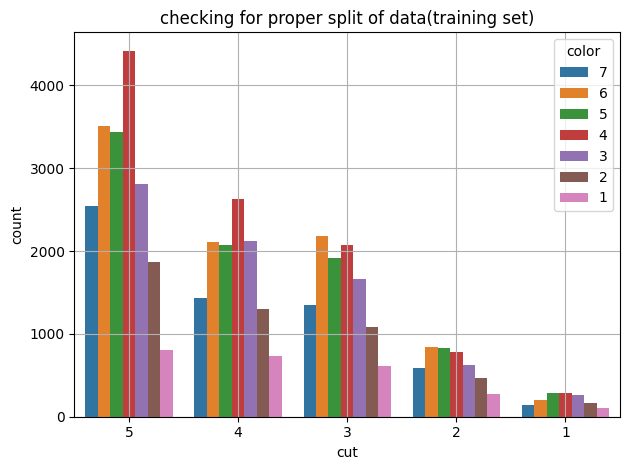

In [104]:
strat_train_cut = strat_train_set['cut']
strat_train_color = strat_train_set['color']
sns.countplot(x=strat_train_cut,hue=strat_train_color,data=strat_train_set)
plt.title("checking for proper split of data(training set)")
plt.tight_layout()
plt.grid(True)

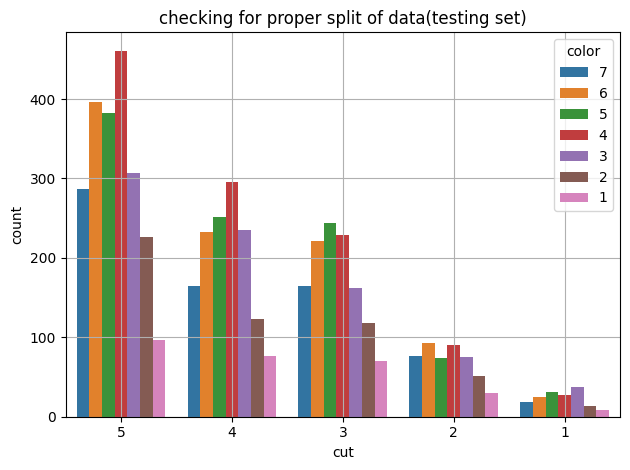

In [105]:
strat_test_cut = strat_test_set['cut']
strat_test_color = strat_test_set['color']
sns.countplot(x=strat_test_cut,hue=strat_test_color,data=strat_test_set)
plt.title("checking for proper split of data(testing set)")
plt.tight_layout()
plt.grid(True)

In [106]:
#separate the features and labels from the training data set
labels = strat_train_set['price_in_indian_rupee'].copy()
features = strat_train_set.drop(['price','price_in_indian_rupee'],axis=1)


In [107]:
#using StandardScaler to minimize all the values to small level it become easy for ML model
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])
prepared_data = num_pipeline.fit_transform(features)

In [108]:
#Loading the Model
model = RandomForestRegressor()
model.fit(prepared_data,labels)

RandomForestRegressor()

In [109]:
#lets check the prediction
#firstly separate the features and labels from the testing datasets
strat_test_set_features = strat_test_set.drop(['price','price_in_indian_rupee'],axis=1)
#firstly transform the data
prepared_test_data = num_pipeline.transform(strat_test_set_features)
prediction = model.predict(prepared_test_data)
print(prediction)

[975365.883 406390.815 459320.184 ... 707096.232 478258.542  62538.183]


In [110]:
prediction.shape

(5392,)

In [111]:
#checking the accuracy of the decision tree model
accuracy = r2_score(strat_test_set['price_in_indian_rupee'],prediction)
print(f"Accuracy (R2 Score) is: {accuracy:.2%}")


Accuracy (R2 Score) is: 98.32%


In [112]:
features

,carat,cut,color,clarity,depth,table,x,y,z
37532,0.31,5,6,7,61.0,57.0,4.36,4.33,2.65
25667,2.04,4,2,2,59.8,59.0,8.30,8.23,4.94
32237,0.30,5,6,6,60.2,57.0,4.37,4.40,2.64
48030,0.64,4,6,4,61.6,62.0,5.48,5.46,3.37
50258,0.70,3,6,3,58.7,60.0,5.85,5.88,3.44
...,...,...,...,...,...,...,...,...,...
53369,0.71,5,6,3,61.7,56.0,5.72,5.75,3.54
9726,1.26,5,1,2,62.5,53.0,6.86,6.90,4.30
51157,0.73,4,5,3,62.4,55.0,5.78,5.71,3.59
12474,1.21,2,2,3,62.7,59.0,6.63,6.71,4.18


In [113]:
model2 = DecisionTreeRegressor()
model2.fit(prepared_data,labels)

DecisionTreeRegressor()

In [117]:
#lets check the prediction
#firstly separate the features and labels from the testing datasets
strat_test_set_features = strat_test_set.drop(['price','price_in_indian_rupee'],axis=1)
#firstly transform the data
prepared_test_data = num_pipeline.transform(strat_test_set_features)
prediction = model2.predict(prepared_test_data)
print(prediction)

[942199.2 435757.5 488433.6 ... 704819.7 454343.4  65676.6]


In [118]:
#checking the accuracy of the decision tree model
accuracy = r2_score(strat_test_set['price_in_indian_rupee'],prediction)
print(f"Accuracy (R2 Score) is: {accuracy:.2%}")

Accuracy (R2 Score) is: 96.76%


In [119]:
model3 = LinearRegression()
model3.fit(prepared_data,labels)

LinearRegression()

In [120]:
#lets check the prediction
#firstly separate the features and labels from the testing datasets
strat_test_set_features = strat_test_set.drop(['price','price_in_indian_rupee'],axis=1)
#firstly transform the data
prepared_test_data = num_pipeline.transform(strat_test_set_features)
prediction = model3.predict(prepared_test_data)
print(prediction)

[722168.17002277 398201.36979713 466914.79004697 ... 866703.20449575
 462623.65863914  72936.08799462]


In [121]:
#checking the accuracy of the linear regressor model
accuracy = r2_score(strat_test_set['price_in_indian_rupee'],prediction)
print(f"Accuracy (R2 Score) is: {accuracy:.2%}")

Accuracy (R2 Score) is: 91.09%


In [123]:
#doing feature Engineering to add one more column in the dataset.

In [129]:
copy_diamonds_data_more_feature = copy_diamonds_data.copy()
copy_diamonds_data_more_feature['volumn'] = copy_diamonds_data_more_feature['x']*copy_diamonds_data_more_feature['y']*copy_diamonds_data_more_feature['z']
copy_diamonds_data_more_feature

,carat,cut,color,clarity,depth,table,price,x,y,z,price_in_indian_rupee,volumn
0,0.23,5,6,2,61.5,55.0,326,3.95,3.98,2.43,31393.8,38.202030
1,0.21,4,6,3,59.8,61.0,326,3.89,3.84,2.31,31393.8,34.505856
2,0.23,2,6,5,56.9,65.0,327,4.05,4.07,2.31,31490.1,38.076885
3,0.29,4,2,4,62.4,58.0,334,4.20,4.23,2.63,32164.2,46.724580
4,0.31,2,1,2,63.3,58.0,335,4.34,4.35,2.75,32260.5,51.917250
...,...,...,...,...,...,...,...,...,...,...,...,...
53915,0.72,5,7,3,60.8,57.0,2757,5.75,5.76,3.50,265499.1,115.920000
53916,0.72,2,7,3,63.1,55.0,2757,5.69,5.75,3.61,265499.1,118.110175
53917,0.70,3,7,3,62.8,60.0,2757,5.66,5.68,3.56,265499.1,114.449728
53918,0.86,4,3,2,61.0,58.0,2757,6.15,6.12,3.74,265499.1,140.766120


In [130]:
copy_diamonds_data_more_feature.describe()

,carat,depth,table,price,x,y,z,price_in_indian_rupee,volumn
count,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,53920.000000,5.392000e+04,53920.000000
mean,0.797698,61.749514,57.456834,3930.993231,5.731627,5.734887,3.540046,3.785546e+05,129.897567
std,0.473795,1.432331,2.234064,3987.280446,1.119423,1.140126,0.702530,3.839751e+05,78.219789
min,0.200000,43.000000,43.000000,326.000000,3.730000,3.680000,1.070000,3.139380e+04,31.707984
25%,0.400000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000,9.138870e+04,65.189759
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000,2.312163e+05,114.840180
75%,1.040000,62.500000,59.000000,5323.250000,6.540000,6.540000,4.040000,5.126290e+05,170.846415
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000,1.812655e+06,3840.598060


In [131]:
split = StratifiedShuffleSplit(n_splits=1,test_size=0.1,random_state=78)
for train_index,test_index in split.split(copy_diamonds_data_more_feature,copy_diamonds_data_more_feature['cut']):
  strat_train_set_more_feature = copy_diamonds_data_more_feature.loc[train_index]
  strat_test_set_more_feature = copy_diamonds_data_more_feature.loc[test_index]

In [132]:
#Now Again separate the features and labels from the training data set
labels = strat_train_set_more_feature['price_in_indian_rupee'].copy()
features = strat_train_set_more_feature.drop(['price','price_in_indian_rupee'],axis=1)

In [135]:
#using StandardScaler again
num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])
prepared_data_on_more_features = num_pipeline.fit_transform(features)

In [136]:
#Now susing this more features data on different models
randomforest = RandomForestRegressor()
randomforest.fit(prepared_data_on_more_features,labels)

decisiontree = DecisionTreeRegressor()
decisiontree.fit(prepared_data_on_more_features,labels)

linearmodel = LinearRegression()
linearmodel.fit(prepared_data_on_more_features,labels)

LinearRegression()

In [137]:
#lets check the predictionagain on more features data
#firstly separate the features and labels from the testing datasets
strat_test_set_features_new = strat_test_set_more_feature.drop(['price','price_in_indian_rupee'],axis=1)
#firstly transform the data
prepared_test_data_on_new_data = num_pipeline.transform(strat_test_set_features_new)
new_prediction = randomforest.predict(prepared_test_data_on_new_data)
print(new_prediction)

[984947.733 409396.338 468062.298 ... 692144.694 468558.243  62800.119]


In [138]:
#checking the accuracy of the RandomForest model again on new data
accuracy = r2_score(strat_test_set_more_feature['price_in_indian_rupee'],new_prediction)
print(f"Accuracy (R2 Score) is: {accuracy:.2%}")

Accuracy (R2 Score) is: 98.32%


In [139]:
#lets check the predictionagain on more features data
#firstly separate the features and labels from the testing datasets
strat_test_set_features_new = strat_test_set_more_feature.drop(['price','price_in_indian_rupee'],axis=1)
#firstly transform the data
prepared_test_data_on_new_data = num_pipeline.transform(strat_test_set_features_new)
new_prediction = decisiontree.predict(prepared_test_data_on_new_data)
print(new_prediction)

[964829.7 405134.1 479574.  ... 586948.5 463780.8  65676.6]


In [140]:
#checking the accuracy of the decision tree model again on new data
accuracy = r2_score(strat_test_set_more_feature['price_in_indian_rupee'],new_prediction)
print(f"Accuracy (R2 score) is {accuracy:.2%}")

Accuracy (R2 score) is 96.99%


In [141]:
#lets check the predictionagain on more features data
#firstly separate the features and labels from the testing datasets
strat_test_set_features_new = strat_test_set_more_feature.drop(['price','price_in_indian_rupee'],axis=1)
#firstly transform the data
prepared_test_data_on_new_data = num_pipeline.transform(strat_test_set_features_new)
new_prediction = linearmodel.predict(prepared_test_data_on_new_data)
print(new_prediction)

[725630.35879042 394859.65270757 464623.5803085  ... 869237.16943479
 461704.95220953  72780.44595459]


In [142]:
#checking the accuracy of the linear model again on new data
accuracy = r2_score(strat_test_set_more_feature['price_in_indian_rupee'],new_prediction)
print(f"Accuracy (R2 score) is {accuracy:.2%}")

Accuracy (R2 score) is 91.11%


In [143]:
#Selecting RandomForestRegressor for hypermeters selecting as it gives more accuracy in default parameters.

In [145]:
#Finding the best parameters for randomforest model
# Define parameters to test
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
# Setup the randomized search
random_search = RandomizedSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1),
                                   param_distributions=param_dist,
                                   n_iter=5, cv=3, random_state=42)
random_search.fit(prepared_data_on_more_features, labels)
print("Best Parameters Found:", random_search.best_params_)

Best Parameters Found: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': 20}


In [147]:
#Traing my model on new data with adjusting the hyperparamters
randomforest_upgraded = RandomForestRegressor(n_estimators=100,min_samples_split=5,max_depth=20,random_state=78)
randomforest_upgraded.fit(prepared_data_on_more_features,labels)

RandomForestRegressor(max_depth=20, min_samples_split=5, random_state=78)

In [150]:
from typing_extensions import final
#lets check the predictionagain on more features data
#firstly separate the features and labels from the testing datasets
strat_test_set_features_new = strat_test_set_more_feature.drop(['price','price_in_indian_rupee'],axis=1)
#firstly transform the data
prepared_test_data_on_new_data = num_pipeline.transform(strat_test_set_features_new)
final_prediction = randomforest_upgraded.predict(prepared_test_data_on_new_data)
print(final_prediction)

[980409.0011289  413946.00156404 465412.49059904 ... 703397.54748907
 467214.44164135  62178.71809805]


In [151]:
#checking the accuracy of the randomforest model once again to check the result after using hyperparameters
accuracy = r2_score(strat_test_set_more_feature['price_in_indian_rupee'],final_prediction)
print(f"Accuracy (R2 score) is {accuracy:.2%}")

Accuracy (R2 score) is 98.34%
